# **Philippine Inflation Rate Forecasting**

This notebook summarizes the performance of baseline, statistical, and machine learning models for forecasting the monthly year-on-year Philippine inflation rate.

**Models evaluated:**

- Naive
- Seasonal Naive
- SARIMA
- SARIMAX
- XGBoost

## **Objective**

This report evaluates baseline, statistical, and machine learning approaches for forecasting the monthly year-on-year Philippine inflation rate. The models are compared according to how they incorporate exogenous variables, and the resulting forecasting performance is evaluated using a common hold-out test set. The best-performing approaches are then used to generate a twelve-month inflation forecast.

## **Dataset**

The target variable is the monthly year-on-year Philippine inflation rate.

The following macroeconomic indicators are used as potential explanatory variables.

| Variable | Purpose |
|-----------|---------|
| USD/PHP exchange rate | Currency movements affecting imported goods |
| Unemployment rate | Indicator of labour market conditions |
| Dubai crude oil price | Energy price proxy |
| BSP Target RRP | Monetary policy indicator |

The processed dataset contains observations from 1958 to 2026. Inflation and exchange rate data span the full period, while the remaining variables begin later, producing missing values when merged into a single dataset.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

In [43]:
inf_data = pd.read_csv('..//data/processed//combined_macro_data.csv', index_col = 0)
inf_data.index = pd.to_datetime(inf_data.index)
inf_data_test = inf_data['InflationRate'][-12:]
inf_data.tail()

,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude,TargetRRP
Date,,,,,
2026-02-01,2.419984,58.280263,5.1,68.508500,4.25
2026-03-01,4.068858,59.406905,5.0,126.706364,4.25
2026-04-01,7.227023,60.291316,4.7,105.299091,4.50
2026-05-01,6.761006,61.441000,4.8,100.364286,4.50
2026-06-01,6.362922,61.251300,4.8,79.539545,4.75


In [5]:
inf_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 822 entries, 1958-01-01 to 2026-06-01
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   InflationRate     822 non-null    float64
 1   USD_PHP           822 non-null    float64
 2   UnemploymentRate  258 non-null    float64
 3   DubaiCrude        414 non-null    float64
 4   TargetRRP         476 non-null    float64
dtypes: float64(5)
memory usage: 38.5 KB


## **Complete and Reduced Datasets**

Two datasets are used throughout this report. The complete dataset contains every available inflation observation and is used by models that do not require exogenous variables. Models using exogenous variables require complete observations for every predictor. Restricting the data to complete cases reduces the sample size from 822 observations to 258 observations. This distinction is important because the reduced dataset provides additional explanatory variables at the expense of substantially fewer training observations.

In [7]:
inf_data.describe()

,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude,TargetRRP
count,822.000000,822.000000,258.000000,414.000000,476.000000
mean,7.908864,27.407800,6.535116,53.731706,7.027736
std,8.406149,19.965500,1.927484,31.965323,3.900227
min,-2.205882,2.000000,3.070000,10.080500,2.000000
25%,3.009064,7.032677,5.290000,23.168290,4.000000
50%,5.812458,25.730435,6.570000,53.575974,6.250000
75%,9.803922,47.623216,7.400000,76.308030,9.000000
max,63.333333,61.441000,17.600000,130.082609,27.500000


In [11]:
inf_data.dropna().describe()

,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude,TargetRRP
count,258.000000,258.000000,258.000000,258.000000,258.000000
mean,3.868377,49.478036,6.535116,74.013489,4.503876
std,2.078275,5.176381,1.927484,22.850261,1.532554
min,-0.372787,40.671100,3.070000,26.192727,2.000000
25%,2.468741,44.881461,5.290000,56.858246,3.500000
50%,3.660689,49.170600,6.570000,71.946266,4.000000
75%,4.915284,53.244310,7.400000,90.668469,5.687500
max,10.541586,61.441000,17.600000,130.082609,7.500000


## **Modeling Strategy**

Two forecasting settings are investigated:

**1. Univariate forecasting**\
   Inflation is forecast using only historical inflation values.

**2. Forecasting with predicted exogenous variables**\
   Future macroeconomic variables are forecast separately before being supplied to the forecasting model.

Hyperparameters were selected using expanding-window cross-validation to preserve temporal ordering.

## **Limitations**

- Only approximately 250 observations contain complete exogenous information.
- Future macroeconomic variables are assumed to be unknown, which often happens in practice, and must themselves be forecasted.
- Machine learning models require substantially more observations than classical time-series models.
- Forecast uncertainty increases with prediction horizon due to recursive forecasting.

## **Model Evaluation**

The following forecasting approaches are compared.

| Model | Description |
|--------|-------------|
| Naive | Previous observation |
| Seasonal Naive | Previous seasonal observation |
| SARIMA | Univariate statistical model |
| SARIMAX | Statistical model with exogenous variables |
| XGBoost | Machine learning regression model |

These models are evaluated using the same hold-out test period. Three metrics are reported.

- RMSE measures the magnitude of forecasting error.
- MAE measures the average absolute prediction error.
- $R^2$ measures the fraction of variance explained.

Lower RMSE and MAE indicate better predictive performance, whereas larger $R^2$ values indicate improved explanatory power.

In [12]:
naive_test = pd.read_csv('..//outputs//tests//naive_test.csv', index_col = 0)
seasonal_naive_test = pd.read_csv('..//outputs//tests//seasonal_naive_test.csv', index_col = 0)
sarima_full_test = pd.read_csv('..//outputs//tests//sarima_full_test.csv', index_col = 0)
sarima_red_test = pd.read_csv('..//outputs//tests//sarima_red_test.csv', index_col = 0)
sarimax_test = pd.read_csv('..//outputs//tests//sarimax_test.csv', index_col = 0)
xgboost_full_test = pd.read_csv('..//outputs//tests//xgboost_full_test.csv', index_col = 0)
xgboost_red_test = pd.read_csv('..//outputs//tests//xgboost_red_test.csv', index_col = 0)
xgboost_exog_test = pd.read_csv('..//outputs//tests//xgboost_exog_test.csv', index_col = 0)

In [13]:
models_test = pd.concat([naive_test, seasonal_naive_test, sarima_full_test, sarima_red_test, sarimax_test, xgboost_full_test, xgboost_red_test, xgboost_exog_test])
models_test

,RMSE,MAE,R2
Naive,2.864234,1.881748,-0.670070
Seasonal Naive,3.065220,2.332447,-0.912674
SARIMA (Full),2.459457,1.707026,-0.231391
SARIMA (Red),2.272876,1.484162,-0.051645
SARIMAX,1.510686,1.053382,0.535414
XGBoost (Full),2.384975,1.472838,-0.157937
XGBoost (Red),2.833683,1.837317,-0.634633
XGBoost (Red w/ Exog),2.841593,1.872614,-0.643770


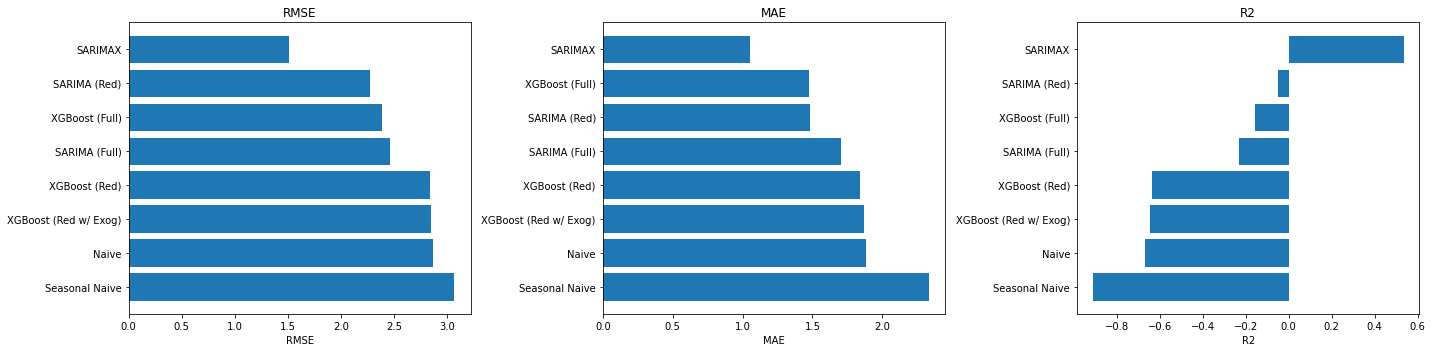

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

metrics = ["RMSE", "MAE", "R2"]

for ax, metric in zip(axes, metrics):
    ascending = metric != "R2"
    data = models_test.sort_values(metric, ascending=ascending)

    ax.barh(data.index, data[metric])
    ax.set_title(metric)
    ax.set_xlabel(metric)

    if metric == "R2":
        ax.invert_yaxis()  
    else:
        ax.invert_yaxis()  

plt.tight_layout()
plt.show()

## **Results**

SARIMAX produced the lowest forecasting error across all evaluated models. Although XGBoost can model nonlinear relationships, it did not outperform the statistical approaches. The reduction in training observations caused by requiring complete exogenous variables likely limited its ability to generalize. The Naive and Seasonal Naive models provide useful baselines but were consistently outperformed by SARIMA-based models.

In [75]:
naive_forecast = pd.read_csv('../outputs//forecasts//naive_forecast.csv', index_col=0)
seasonal_naive_forecast = pd.read_csv('../outputs//forecasts//seasonal_naive_forecast.csv', index_col=0)
sarima_full_forecast = pd.read_csv('../outputs//forecasts//full_nexog_forecast.csv', index_col=0)
sarima_red_forecast = pd.read_csv('../outputs//forecasts//red_nexog_forecast.csv', index_col=0)
sarimax_forecast = pd.read_csv('../outputs//forecasts//red_exog_forecast.csv', index_col=0)
xgboost_full_forecast = pd.read_csv('../outputs//forecasts//xgboost_full_nexog_forecast.csv', index_col=0)
xgboost_red_forecast = pd.read_csv('../outputs//forecasts//xgboost_red_nexog_forecast.csv', index_col=0)
xgboost_exog_forecast = pd.read_csv('../outputs//forecasts//xgboost_exog_forecast.csv', index_col=0)

models_forecast = pd.concat([
    naive_forecast,
    seasonal_naive_forecast,
    sarima_full_forecast.iloc[:,0],
    sarima_red_forecast.iloc[:,0],
    sarimax_forecast.iloc[:,0],
    xgboost_full_forecast,
    xgboost_red_forecast,
    xgboost_exog_forecast
], axis=1)

models_forecast.index = pd.to_datetime(models_forecast.index)
models_forecast

,Naive,Seasonal Naive,NExog Full Forecast,NExog Reduced Forecast,Exog Reduced Forecast,XGBoost NExog Full Forecast,XGBoost NExog Red Forecast,XGBoost Exog Forecast
2026-07-01,6.362922,0.948617,6.483613,6.577602,6.606598,8.095988,6.969138,6.774942
2026-08-01,6.362922,1.500790,6.348022,6.555966,6.357190,8.062081,6.956394,6.208397
2026-09-01,6.362922,1.741884,6.655733,6.839363,6.698282,8.912901,7.247440,5.954680
2026-10-01,6.362922,1.660079,6.870554,6.789446,6.835978,9.917969,7.247440,5.457502
2026-11-01,6.362922,1.496063,7.126533,6.816052,7.110916,8.921079,7.024276,5.417151
2026-12-01,6.362922,1.801096,6.736401,6.510117,6.571148,11.395188,6.966479,5.141675
2027-01-01,6.362922,2.024922,6.772204,6.379686,6.546673,7.377362,6.847316,5.001602
2027-02-01,6.362922,2.419984,6.803865,6.388206,6.529246,11.550593,6.757061,4.943663
2027-03-01,6.362922,4.068858,5.690923,5.488318,5.287970,6.884830,6.397073,4.996458
2027-04-01,6.362922,7.227023,3.494100,3.674662,2.887162,9.872710,6.068601,4.391084


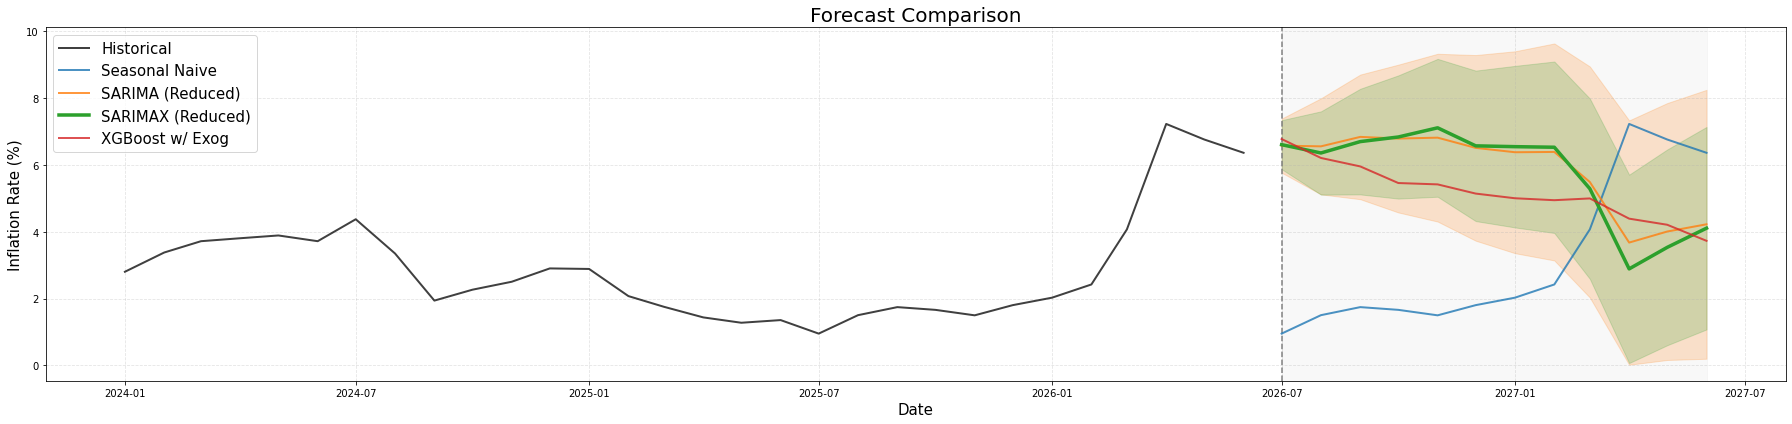

In [80]:
plt.figure(figsize=(25,6))

sarimax_forecast.index = pd.to_datetime(sarimax_forecast.index)
sarima_red_forecast.index = pd.to_datetime(sarima_red_forecast.index)

forecast_start = models_forecast.index[0]

plt.axvspan(forecast_start, models_forecast.index[-1], color='lightgray', alpha=0.15, zorder=0)
plt.axvline(forecast_start, color='gray', linestyle='--', linewidth=1.5)

plt.plot(inf_data['InflationRate']['2024':], color='black', linewidth=2, alpha=0.75, label='Historical')

imp = [
    'Seasonal Naive',
    'NExog Reduced Forecast',
    'Exog Reduced Forecast',
    'XGBoost Exog Forecast'
]

name = ['Seasonal Naive', 'SARIMA (Reduced)', 'SARIMAX (Reduced)', 'XGBoost w/ Exog']

for i in range(len(imp)):
    lw = 3.5 if imp[i] == 'Exog Reduced Forecast' else 2
    alpha = 1.0 if imp[i] == 'Exog Reduced Forecast' else 0.8
    line = plt.plot(models_forecast.index, models_forecast[imp[i]], linewidth=lw, alpha=alpha, label=name[i])[0]
    color = line.get_color()

    if imp[i] == 'Exog Reduced Forecast':
        plt.fill_between(models_forecast.index, sarimax_forecast['Low'], sarimax_forecast['High'], color=color, alpha=0.20)

    if imp[i] == 'NExog Reduced Forecast':
        plt.fill_between(models_forecast.index, sarima_red_forecast['Low'], sarima_red_forecast['High'], color=color, alpha=0.20)

plt.title('Forecast Comparison', fontsize=20)
plt.xlabel('Date', fontsize=15)
plt.ylabel('Inflation Rate (%)', fontsize=15)
plt.grid(alpha=0.35, linestyle='--')
plt.legend(fontsize=15, frameon=True)
plt.tight_layout()
plt.savefig('..//outputs//figures//forecast_comparison.jpg', dpi = 300, bbox_inches = 'tight')
plt.savefig('..//outputs//figures//forecast_comparison.png', dpi = 300, bbox_inches = 'tight')
plt.show()

## **Forecast Comparison**

The forecasting models exhibit distinct long-term behaviour. Seasonal Naive repeats the inflation values observed during the previous year. SARIMA and SARIMAX produce comparatively smooth trajectories, reflecting their autoregressive structure. In contrast, XGBoost forecasts decline more rapidly over the prediction horizon because each forecast is recursively used as input for subsequent predictions. Prediction intervals widen with forecast horizon, indicating increasing uncertainty in longer-term forecasts. Among the evaluated approaches, SARIMAX provides the most stable trajectory while also achieving the lowest forecasting error on the test set. 

There is a caveat for SARIMAX, however, that the uncertainty associated with forecasting the exogenous variables is not reflected in the reported prediction intervals. As a consequence, the true forecast uncertainty is likely larger than shown.

## **Discussion**

Among the evaluated models, SARIMAX achieved the strongest predictive performance. The improvement obtained from incorporating exogenous variables suggests that exchange rates, crude oil prices, unemployment, and monetary policy contain useful information for explaining inflation dynamics. Despite its flexibility, XGBoost consistently underperformed the statistical models. The available training data consisted of only approximately 250 complete observations after incorporating exogenous variables, limiting the effectiveness of a data-intensive machine learning approach. These results indicate that classical time-series models remain well suited to monthly macroeconomic forecasting when sample sizes are limited.

## **Conclusions**

- SARIMAX achieved the highest predictive accuracy among the evaluated forecasting models.
- Forecasting with exogenous variables improved predictive performance over univariate approaches.
- XGBoost did not outperform classical statistical time-series models for this monthly dataset.
- Classical statistical time-series models remain effective forecasting methods when only a limited number of observations are available.